# **Proyecto ABP 8: Fundamentos de Deep Learning - Clasificador Inteligente de Imágenes de Ropa**

**Autora:** Bernardita Ortega.

**Dataset:** Fashion-MNIST

**Link**: *https://keras.io/api/datasets/fashion_mnist/*

### **Situación inicial 📍**

#### **Unidad solicitante: Área de Ciencia de Datos de la tienda virtual StyleNet**

La empresa StyleNet, dedicada a la venta de ropa por comercio electrónico, está desarrollando una herramienta que permita clasificar automáticamente
imágenes de productos subidas por usuarios y vendedores a la plataforma. Actualmente, esta tarea se realiza de forma manual, lo cual genera retrasos y errores de categorización. El equipo de ciencia de datos necesita una solución basada en Deep Learning que automatice este proceso, mejorando la eficiencia operativa y la precisión de las etiquetas.


### **Nuestro objetivo 📋**
Diseñar, entrenar e implementar un modelo basado en redes neuronales que sea capaz de clasificar imágenes de prendas de vestir (camisetas, zapatillas, pantalones, etc.) en sus respectivas categorías. Al finalizar el módulo, se espera contar con un prototipo funcional construido en Python utilizando Keras o PyTorch, capaz de predecir la categoría de una imagen con alto nivel de exactitud.

## **Lección 1 - *La Red Neuronal Artificial***

📌 **Objetivo:** Comprender los elementos de una red neuronal artificial y su rol en la resolución de problemas.

📍 **Tareas solicitadas en el ejercicio:**
1. Definir la arquitectura de una red neuronal densa.
2. Implementar una red neuronal simple para clasificación binaria.
3. Identificar capas, pesos, funciones de activación y pérdida.

Una **red neuronal artificial (RNA)** es un modelo computacional inspirado en la estructura del cerebro humano. Estas redes están compuestas por unidades llamadas "neuronas artificiales", que se organizan en capas y se interconectan entre sí mediante pesos. Las redes neuronales son capaces de aprender a partir de datos, generalizando patrones y realizando predicciones con gran precisión.


El **perceptrón** es la unidad básica de una red neuronal. En su forma más simple, un perceptrón toma varias entradas, las multiplica por pesos, las suma y pasa el resultado por una función de activación.

Cada perceptrón tiene un **sesgo (b o bias)** que permite ajustar el umbral de activación, desplazandola hacia la izquierda o derecha. Es fundamental para que el modelo pueda representar correctamente ciertos patrones. Además, los **pesos (w)** determinan la importancia de cada entrada en el resultado de una neurona. Se inicializan aleatoriamente y se ajustan durante el entrenamiento para minimizar el error, permitiendo que el perceptrón "aprenda".

Una red neuronal puede considerarse como una pila de perceptrones conectados en capas. Las cuales defineremos a continuación:
1. **Capa de entrada**: recibe los datos en bruto. Su número de neuronas equivale al número de características de entrada.

2. **Capas ocultas**: procesamiento intermedio de la información mediante funciones de activación. Capturan relaciones no lineales. Pueden ser una o múltiples, dependiendo del problema.

| Función de Activación | Fórmula | Uso principal |
|---|---|---|
| **Sigmoid** | 1 / (1 + e⁻ˣ) | Clasificación binaria (capa salida) |
| **Tanh** | (eˣ - e⁻ˣ) / (eˣ + e⁻ˣ) | Redes antiguas |
| **ReLU** | max(0, x) | Redes profundas (deep). Capas ocultas (eficiente, evita gradiente desvanecido) |
| **Softmax** | eˣⁱ / Σeˣʲ | Clasificación multiclase (capa salida) |

3. **Capa de salida**: genera la predicción o resultado. Puede tener una o más neuronas, según la tarea: clasificación binaria (1 neurona), multiclase (n neuronas) o regresión.

Las capas ocultas son las responsables de capturar relaciones complejas. Cuantas más capas y neuronas haya, mayor será la capacidad de aprendizaje, aunque también aumenta el riesgo de sobreajuste y el costo computacional.

Una **red neuronal densa** es un tipo de arquitectura donde cada neurona está conectada a todas las neuronas de la capa siguiente.

Características clave:
- Las conexiones completas permiten una gran capacidad de aprendizaje.
- Se utilizan en tareas de clasificación y regresión general.
- No considera estructuras espaciales o temporales como sí lo hacen las redes convolucionales o recurrentes.

La arquitectura se define según:
- Número de capas ocultas.
- Número de neuronas por capa.
- Funciones de activación utilizadas.
- Estrategia de regularización (dropout, L2, etc.).

Esta estructura es versátil y representa el tipo de red más utilizado en contextos educativos y aplicaciones generales.

Ciclo de Entrenamiento:
```
Datos de Entrada → [Forward Pass] → Predicción → [Loss] → Error → [Backpropagation] → Ajuste de Pesos
```

- **Forward Pass (Propagación Hacia Adelante)**:
proceso mediante el cual los datos pasan por la red,
desde la capa de entrada hasta la de salida, generando
una predicción. Se aplican funciones de activación y se
computa la pérdida.

- **Loss Function (Función de Pérdida)**: Es una función que cuantifica el error entre la predicción de la red y el valor real. Las más comunes son: MSE (Error cuadrático medio) para problemas de regresión y Cross-Entropy para problemas de clasificación.

- **Backpropagation (Retropropagación)**: Una vez calculado el error, este se propaga hacia atrás (backward pass), actualizando los pesos mediante el
algoritmo de descenso de gradiente.

**Implementar una red neuronal simple para clasificación binaria**

El modelo recibe una entrada y debe responder una de dos opciones: 0 o 1. Por ejemplo: es spam / no es spam, tiene enfermedad / no tiene enfermedad, aprueba / no aprueba.

```
Datos de Entradas (X) → [Capas ocultas] → 1 neurona de salida → probabilidad
```

**El ciclo de entrenamiento**
1. **Entrada** de datos por la izquierda
2. **Forward pass**: se propagan capa por capa hasta producir una predicción.
    - z = w·x + b          → suma ponderada
    - pred = sigmoid(z) = 1 / (1 + e^(-z))    → activación

    La neurona de salida usa sigmoid, que toma cualquier número real y lo comprime al rango [0, 1]: Si el resultado es ≥ 0.5 → clase 1. Si el resultado es < 0.5 → clase 0

3. **Calcular la pérdida**: se compara la predicción con el valor real usando Binary Cross-Entropy. Mientras más alta la pérdida, más se equivocó el modelo.
    - Si el modelo predijo 0.95 y era 1 → pérdida muy baja
    - Si el modelo predijo 0.05 y era 1 → pérdida muy alta
    - Si el modelo predijo 0.50 → pérdida intermedia (máxima incertidumbre)
4. **Backpropagation**: el error se propaga hacia atrás calculando el gradiente, es decir, cuánto contribuyó cada peso al error cometido.
5. **Actualización de pesos**: se ajustan los pesos en la dirección opuesta al gradiente para reducir el error:
  w = w - lr · gradiente
El learning rate (lr) controla el tamaño del paso.
    - Muy alto → el modelo no converge.
    - Muy bajo → aprende muy lento.
6. Repetir durante N épocas hasta que la pérdida converge.

## **Lección 2 - *Deep Learning***

📌 **Objetivo:** Reconocer las principales arquitecturas, usos y frameworks de Deep Learning.

📍 **Tareas solicitadas en el ejercicio:**
1. Investigar y documentar la arquitectura óptima para clasificación de imágenes.
2. Justificar la elección entre red densa vs. convolutiva.
3. Seleccionar el framework a utilizar: Keras o PyTorch.

Existen diversas arquitecturas dentro del Deep Learning, cada una con ventajas según el tipo de dato o tarea a resolver:

- **Redes Neuronales Densas (DNN)**:
  - *Aplicación principal*: Clasificación y regresión genérica
  - *Características clave*: Totalmente conectadas, versátiles. Buenas para datos tabulares.

- **Redes Neuronales Convolucionales (CNN)**:
  - *Aplicación principal*: Visión por computadora.
  - *Características clave*: Tipo de datos: Imágenes. Detectan patrones espaciales locales (bordes, texturas, formas). Reducen parámetros mediante convoluciones.

- **Redes Neuronales Recurrentes (RNN / LSTM)**:
  - *Aplicación principal*: Procesamiento secuencial (texto, audio)
  - *Características clave*: Memoria de secuencia, manejo de contexto. Puede tener problemas con secuencias largas.

- **Autoencoders**:
  - *Aplicación principal*: Compresión y reducción de dimensionalidad.
  - *Características clave*: Aprendizaje no supervisado

- **Transformers**:
  - *Aplicación principal*: NLP y visión moderna
  - *Características clave*: Paralelismo, atención global, transfer learning.

Por lo tanto, la arquitectura óptima para clasificación de imágenes es la **Red Convolutiva (CNN)**. Ya que trabaja directamente sobre la imagen en 2D (28×28×1). Aplicando filtros que recorren la imagen detectando patrones locales: bordes, texturas, formas.

En cambio la **Red Densa (Perceptrón Multicapa o MLP)** aplana la imagen de 28×28 píxeles en un vector de 784 valores. Cada neurona se conecta con todas las de la capa siguiente, sin importar si los píxeles son vecinos o no. Trata cada píxel como una característica independiente, perdiendo completamente la estructura espacial de la imagen.


### **Frameworks para Deep Learning**

Los frameworks son bibliotecas de programación que facilitan la implementación de modelos de Deep Learning. Los más utilizados actualmente son:
| Framework | Lenguaje base | Características principales | Cuándo elegirlo |
|---|---|---|---|
| TensorFlow | Python / C++ | Soporta producción, escalable, mantiene Google, alto rendimiento | Producción |
| Keras | Python | API de alto nivel sobre TensorFlow. Más legible y amigable que TensorFlow puro. | Prototipado rápido |
| PyTorch | Python / C++ | Desarrollado por Facebook (Meta). Flexible, dinámico, preferido en investigación. | Investigación |

La elección del framework depende del objetivo: si se busca rapidez y simplicidad, Keras es ideal; si se necesita control y flexibilidad, PyTorch es la opción preferida; y para producción robusta, TensorFlow se destaca.

En este caso, usaremos Keras, ya que ofrece una API de alto nivel simple y legible, ideal para prototipado rápido.

## **Lección 3 - *Implementación de RN en Python (Red Densa)***

📌 **Objetivo:** Diseñar y entrenar una red neuronal con Python para resolver un problema de clasificación.

📍 **Tareas solicitadas en el ejercicio:**
1. Implementar un modelo funcional para clasificar imágenes del dataset Fashion-MNIST.
2. Entrenar y validar el modelo usando diferentes hiperparámetros.
3. Aplicar técnicas de optimización y regularización.

In [1]:
# Importar librerías
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import fashion_mnist  # Dataset fashion_mnist para la tarea
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [2]:
# Cargar dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

CLASS_NAMES = ['Remera/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Cartera', 'Bota']

print(f'X_train shape: {X_train.shape}')
print(f'X_test  shape: {X_test.shape}')
print(f'Rango de píxeles: [{X_train.min()}, {X_train.max()}]')

X_train shape: (60000, 28, 28)
X_test  shape: (10000, 28, 28)
Rango de píxeles: [0, 255]


El resultado significa 60.000 imágenes, cada una de 28×28 píxeles para el entrenamiento y 10.000 imágenes para el testeo.

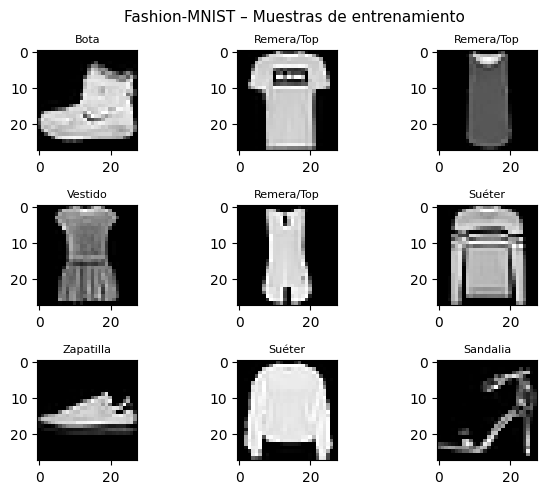

In [3]:
# Exploración visual del dataset
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.tight_layout()
    plt.imshow(X_train[i], cmap='gray', interpolation='none')
    plt.title(f'{CLASS_NAMES[y_train[i]]}', fontsize=8)
plt.suptitle('Fashion-MNIST – Muestras de entrenamiento', fontsize=11, y=1.02)
plt.show()

In [4]:
# Preprocesamiento
# Escalar datos: [0, 255] → [0.0, 1.0]
X_train = X_train / 255
X_test  = X_test  / 255

# Aplanar: (60000, 28, 28) → (60000, 784)
X_train_flat = X_train.reshape((60000, 784))
X_test_flat  = X_test.reshape((10000, 784))

# Convertir etiquetas (0 a 9) a one-hot
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test,  10)

print(f'Shape para MLP – X_train: {X_train_flat.shape}')
print(f'y_train original : {y_train[:3]}')
print(f'y_train one-hot  :\n{y_train_cat[:3]}')

Shape para MLP – X_train: (60000, 784)
y_train original : [9 0 0]
y_train one-hot  :
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [5]:
# Definir y compilar modelo
mlp_simple = Sequential()
mlp_simple.add(Input(shape=(784,)))              # capa entrada: 784 píxeles
mlp_simple.add(Dense(128, activation='relu'))    # capa oculta
mlp_simple.add(Dense(10,  activation='softmax')) # capa salida: 10 clases

mlp_simple.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

mlp_simple.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Entrenamiento - MLP Simple
history_simple = mlp_simple.fit(X_train_flat, y_train_cat,
                                 epochs=15,
                                 batch_size=64,
                                 validation_split=0.1)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8172 - loss: 0.5292 - val_accuracy: 0.8493 - val_loss: 0.4275
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8607 - loss: 0.3928 - val_accuracy: 0.8687 - val_loss: 0.3741
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8726 - loss: 0.3555 - val_accuracy: 0.8745 - val_loss: 0.3510
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8811 - loss: 0.3244 - val_accuracy: 0.8780 - val_loss: 0.3441
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8886 - loss: 0.3053 - val_accuracy: 0.8795 - val_loss: 0.3360
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8947 - loss: 0.2899 - val_accuracy: 0.8798 - val_loss: 0.3325
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8979 - loss: 0.2767 - val_accuracy: 0.8775 - val_loss: 0.3456
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9016 - loss: 0.2674 - val_accuracy: 0.

El modelo termina con 92.11% de accuracy en entrenamiento y 89.22% en validación. La brecha entre ambas métricas se abre a partir de la época 8, lo que indica overfitting leve. Esto justifica probar un learning rate más bajo en el siguiente modelo.

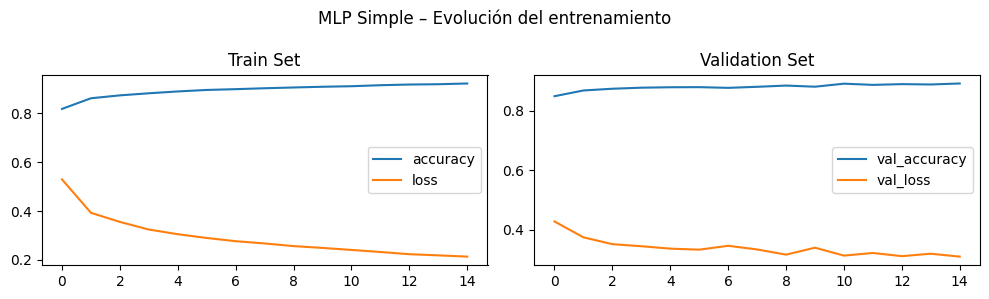

In [17]:
# Visualización Entrenamiento
plt.figure(figsize=(10, 3))
plt.suptitle('MLP Simple – Evolución del entrenamiento', fontsize=12)

plt.subplot(1, 2, 1)
plt.title('Train Set')
plt.plot(history_simple.history['accuracy'], label='accuracy')
plt.plot(history_simple.history['loss'],     label='loss')
plt.legend(loc=0)

plt.subplot(1, 2, 2)
plt.title('Validation Set')
plt.plot(history_simple.history['val_accuracy'], label='val_accuracy')
plt.plot(history_simple.history['val_loss'],     label='val_loss')
plt.legend(loc=0)

plt.tight_layout()
plt.show()

**Train Set (izquierda):**
- La accuracy sube de forma constante.
- La loss baja de forma constante.

**Validation Set (derecha):**
- La val_accuracy sube,  pero se estabiliza a partir de la época 8.
- La val_loss empieza a oscilar desde la época 7 en adelante.

Esa diferencia entre el Train Set y el Validation Set es overfitting leve. La accuracy de entrenamiento sigue subiendo, pero la de validación se estanca.

**Definición de Hiperparámetros y Regularización:**
| Técnica | Descripción | Efecto |
|---|---|---|
| **Learning Rate** | Tamaño del paso en gradiente | LR alto → diverge; LR bajo → lento |
| **Batch Size** | Muestras por iteración | Mayor = más estable, menos noise |
| **Epochs** | Pasadas completas al dataset | Más épocas = riesgo de overfitting |
| **Dropout** | Desactiva neuronas aleatoriamente | Reduce sobreajuste |
| **BatchNorm** | Normaliza activaciones | Estabiliza y acelera entrenamiento |
| **Early Stopping** | Para cuando val_loss empeora | Evita entrenar de más |

**Probar diferentes hiperparámetros**

| Hiperparámetro | Modelo Simple | Modelo lr bajo |
|---|---|---|
| Learning Rate | 0.001 (Adam default) | 0.0001 |
| Batch Size | 64 | 128 |
| Epochs | 15 | 15 |

In [8]:
from tensorflow.keras.optimizers import Adam

# Modelo nuevo con diferentes hiperparámetros: MLP lr bajo
mlp_lr = Sequential()
mlp_lr.add(Input(shape=(784,)))
mlp_lr.add(Dense(128, activation='relu'))
mlp_lr.add(Dense(10,  activation='softmax'))

mlp_lr.compile(optimizer=Adam(learning_rate=0.0001),  # antes 0.001
               loss='categorical_crossentropy',
               metrics=['accuracy'])

history_lr = mlp_lr.fit(X_train_flat, y_train_cat,
                         epochs=15,
                         batch_size=128,              # antes 64
                         validation_split=0.1)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6947 - loss: 0.9703 - val_accuracy: 0.7915 - val_loss: 0.6417
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8087 - loss: 0.5867 - val_accuracy: 0.8185 - val_loss: 0.5367
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8302 - loss: 0.5151 - val_accuracy: 0.8288 - val_loss: 0.4925
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8399 - loss: 0.4777 - val_accuracy: 0.8393 - val_loss: 0.4657
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8480 - loss: 0.4535 - val_accuracy: 0.8452 - val_loss: 0.4523
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8525 - loss: 0.4354 - val_accuracy: 0.8483 - val_loss: 0.4355
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8580 - loss: 0.4214 - val_accuracy: 0.8507 - val_loss: 0.4191
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8609 - loss: 0.4090 - val_accuracy: 0.

Este modelo termina con 87.62% de accuracy en entrenamiento y 86.63% en validación. La brecha entre ambas es mínima, lo que indica que prácticamente no hay overfitting. Sin embargo, el accuracy final es menor que el modelo anterior porque el learning rate más bajo aprende más lento y necesitaría más épocas para converger.

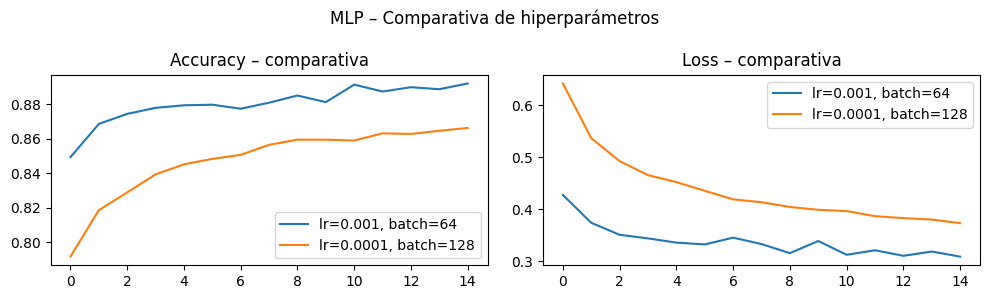

In [19]:
# Comparar modelos
plt.figure(figsize=(10, 3))
plt.suptitle('MLP – Comparativa de hiperparámetros', fontsize=12)

plt.subplot(1, 2, 1)
plt.title('Accuracy – comparativa')
plt.plot(history_simple.history['val_accuracy'], label='lr=0.001, batch=64')
plt.plot(history_lr.history['val_accuracy'],     label='lr=0.0001, batch=128')
plt.legend(loc=0)

plt.subplot(1, 2, 2)
plt.title('Loss – comparativa')
plt.plot(history_simple.history['val_loss'], label='lr=0.001, batch=64')
plt.plot(history_lr.history['val_loss'],     label='lr=0.0001, batch=128')
plt.legend(loc=0)

plt.tight_layout()
plt.show()

El learning rate más alto aprende más rápido y llega a mejor accuracy, pero el learning rate más bajo es más estable y generaliza mejor. Ninguno es "mejor" en absoluto, dependerá de cuál es nuestra prioridad: la velocidad o la estabilidad.

## **Lección 4 - *Redes Neuronales Convolutivas (CNN)***

📌 **Objetivo:** Integrar una red convolutiva para mejorar la capacidad predictiva del modelo.

📍 **Tareas solicitadas en el ejercicio:**
1. Rediseñar la arquitectura utilizando CNN.
2. Evaluar y comparar los resultados con el modelo anterior.
3. Generar predicciones visuales sobre imágenes externas.

In [10]:
# Reshape para CNN: (60000, 28, 28) → (60000, 28, 28, 1)
X_train_cnn = X_train.reshape((60000, 28, 28, 1))
X_test_cnn  = X_test.reshape((10000, 28, 28, 1))

print(f'Shape para CNN – X_train: {X_train_cnn.shape}')

Shape para CNN – X_train: (60000, 28, 28, 1)


In [11]:
# Definir modelo CNN
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten

model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Entrenamiento
history_cnn = model.fit(X_train_cnn, y_train_cat,
                         epochs=15,
                         batch_size=64,
                         validation_split=0.1)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.7751 - loss: 0.6258 - val_accuracy: 0.8425 - val_loss: 0.4320
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - accuracy: 0.8491 - loss: 0.4264 - val_accuracy: 0.8703 - val_loss: 0.3594
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - accuracy: 0.8643 - loss: 0.3817 - val_accuracy: 0.8738 - val_loss: 0.3389
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - accuracy: 0.8738 - loss: 0.3533 - val_accuracy: 0.8873 - val_loss: 0.3103
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - accuracy: 0.8796 - loss: 0.3338 - val_accuracy: 0.8908 - val_loss: 0.2910
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 46ms/step - accuracy: 0.8844 - loss: 0.3179 - val_accuracy: 0.8923 - val_loss: 0.2869
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.8899 - loss: 0.3059 - val_accuracy: 0.8970 - val_loss: 0.2812
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.8912 - loss: 0.2971 - 

La CNN termina con 90.89% de accuracy en entrenamiento y 91.25% en validación. La val_accuracy es incluso mayor que la accuracy, lo que indica que no hay overfitting. Comparado con el MLP simple (92.11% train / 89.22% val), la CNN generaliza mejor aunque su accuracy de entrenamiento es un poco menor.

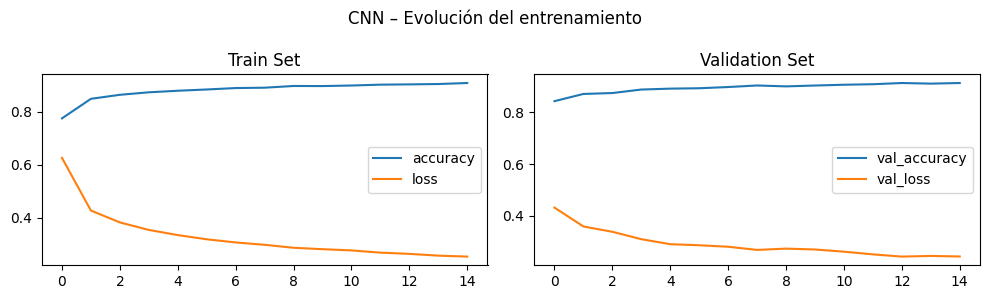

In [20]:
# Visualización
plt.figure(figsize=(10, 3))
plt.suptitle('CNN – Evolución del entrenamiento', fontsize=12)

plt.subplot(1, 2, 1)
plt.title('Train Set')
plt.plot(history_cnn.history['accuracy'], label='accuracy')
plt.plot(history_cnn.history['loss'],     label='loss')
plt.legend(loc=0)

plt.subplot(1, 2, 2)
plt.title('Validation Set')
plt.plot(history_cnn.history['val_accuracy'], label='val_accuracy')
plt.plot(history_cnn.history['val_loss'],     label='val_loss')
plt.legend(loc=0)

plt.tight_layout()
plt.show()

In [21]:
# Evaluar y comparar CNN con MLP
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

y_pred = model.predict(X_test_cnn)
y_pred_label = np.argmax(y_pred, axis=1)

# Comparativa con MLP
y_pred_mlp = np.argmax(mlp_simple.predict(X_test_flat), axis=1)

print(f'MLP Simple – Accuracy: {accuracy_score(y_test, y_pred_mlp)*100:.2f}%')
print(f'CNN        – Accuracy: {accuracy_score(y_test, y_pred_label)*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MLP Simple – Accuracy: 88.74%
CNN        – Accuracy: 90.38%


La CNN (90.38%) supera al MLP (88.74%) en casi 2 puntos porcentuales, lo que confirma que la CNN es mejor para imágenes porque aprovecha la estructura espacial 2D.

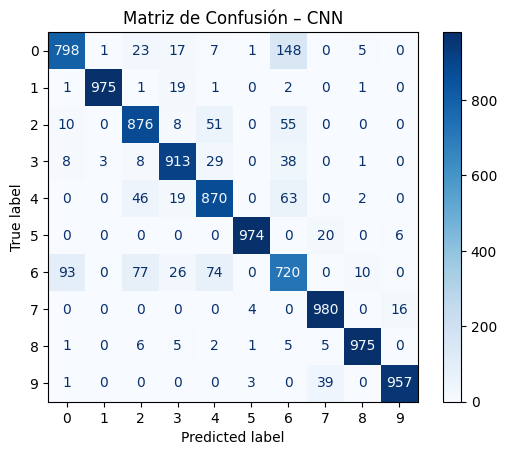


Reporte de Clasificación:
              precision    recall  f1-score   support

  Remera/Top       0.88      0.80      0.83      1000
    Pantalón       1.00      0.97      0.99      1000
      Suéter       0.84      0.88      0.86      1000
     Vestido       0.91      0.91      0.91      1000
      Abrigo       0.84      0.87      0.86      1000
    Sandalia       0.99      0.97      0.98      1000
      Camisa       0.70      0.72      0.71      1000
   Zapatilla       0.94      0.98      0.96      1000
     Cartera       0.98      0.97      0.98      1000
        Bota       0.98      0.96      0.97      1000

    accuracy                           0.90     10000
   macro avg       0.91      0.90      0.90     10000
weighted avg       0.91      0.90      0.90     10000



In [15]:
# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_label)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=np.arange(10))
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión – CNN')
plt.show()

print('\nReporte de Clasificación:')
print(classification_report(y_test, y_pred_label, target_names=CLASS_NAMES))

La **matriz de confusión** se hace para ver dónde se equivoca el modelo, no solo cuánto acierta. La diagonal principal (los números grandes en azul oscuro) son los aciertos, donde la predicción coincide con la etiqueta real. Los números fuera de la diagonal son los errores.

Lo que muestra esta matriz específicamente:
- 0 Remera/Top: tuvo 798 aciertos de 1000. Hay 148 confundidas con Camisa (6).
- 1 Pantalón: tuvo 975 aciertos. Casi sin errores.
- 6 Camisa: tuvo 720 aciertos, siendo la más difícil. Tuvo 93 confundidas con Remera y 77 con Suéter.
- 7 Zapatilla: tuvo 980 aciertos, casi perfecta.

Según el **reporte de clasificación**, la CNN alcanza un 90% de accuracy global. Las clases con mejor desempeño son Pantalón, Sandalia y Cartera con F1 igual o sobre 0,98. La clase más difícil sigue siendo Camisa con F1 de 0,71, ya que el modelo la confunde frecuentemente con Remera y Suéter por su similitud visual.

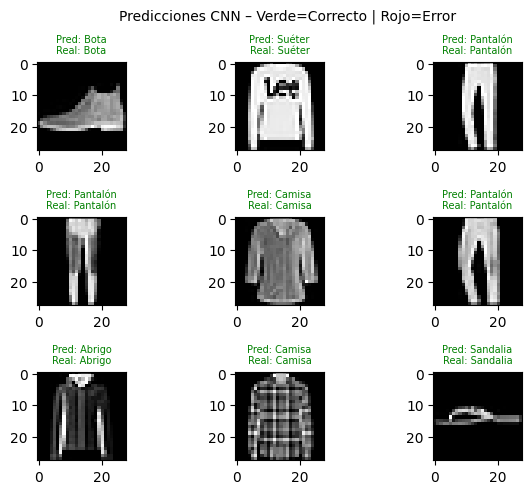

In [16]:
# Predicciones visuales
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.tight_layout()
    plt.imshow(X_test_cnn[i].reshape(28,28), cmap='gray', interpolation='none')
    pred = CLASS_NAMES[y_pred_label[i]]
    real = CLASS_NAMES[y_test[i]]
    color = 'green' if pred == real else 'red'
    plt.title(f'Pred: {pred}\nReal: {real}', fontsize=7, color=color)
plt.suptitle('Predicciones CNN – Verde=Correcto | Rojo=Error', fontsize=10, y=1.02)
plt.show()